In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import precision_at_k, recall_at_k
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

c:\Users\color\AppData\Local\Programs\Python\Python310\lib\site-packages\lightfm\_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
popular_items = pd.read_parquet("../data/processed/popular_items.parquet")
item_features = pd.read_parquet("../data/processed/item_features.parquet")
als_recs = joblib.load("../backend/models/als_recommendations.pkl")
hybrid_recs = joblib.load("../backend/models/hybrid_recommendations.pkl")

train.shape, test.shape

((495761, 5), (74156, 5))

#### 모델 선택 근거 — 비교 테이블

In [4]:
model_comparison = pd.DataFrame({
    "모델": ["인기 추천", "ALS (협업 필터링)", "LightFM (하이브리드)", "Hybrid α=0.1 (채택)"],
    "학습 방식": [
        "구매 빈도 집계",
        "행렬 분해 (Matrix Factorization)",
        "행렬 분해 + 콘텐츠 피처",
        "ALS 점수 + 인기 점수 가중합",
    ],
    "Cold Start 대응": ["O", "X", "O", "부분 (인기 fallback)"],
    "콘텐츠 피처 활용": ["X", "X", "O", "X"],
    "서빙 복잡도": ["낮음", "중간", "높음", "중간"],
    "운영 환경 안정성": ["높음", "높음", "중간 (OS 의존적)", "높음"],
    "채택 여부": ["X", "X", "X — 환경 제약", "O"],
})
model_comparison

,모델,학습 방식,Cold Start 대응,콘텐츠 피처 활용,서빙 복잡도,운영 환경 안정성,채택 여부
0,인기 추천,구매 빈도 집계,O,X,낮음,높음,X
1,ALS (협업 필터링),행렬 분해 (Matrix Factorization),X,X,중간,높음,X
2,LightFM (하이브리드),행렬 분해 + 콘텐츠 피처,O,O,높음,중간 (OS 의존적),X — 환경 제약
3,Hybrid α=0.1 (채택),ALS 점수 + 인기 점수 가중합,부분 (인기 fallback),X,중간,높음,O


####  비교 (인기 / ALS / Hybrid)

In [5]:
article_to_category = (
    item_features.set_index("article_id")["product_type_name"].to_dict()
)
user_history_categories = (
    train.assign(category=train["article_id"].map(article_to_category))
    .groupby("customer_id")["category"]
    .apply(set)
    .to_dict()
)
top_popular_set = set(popular_items["article_id"].head(12).tolist())
total_items = item_features["article_id"].nunique()


def category_hit_rate(rec_list, user_id):
    hist = user_history_categories.get(user_id, set())
    if not hist:
        return 0.0
    rec_cats = {article_to_category.get(a) for a in rec_list if article_to_category.get(a)}
    return len(hist & rec_cats) / len(hist)


def catalog_coverage(recs_dict):
    covered = set()
    for recs in recs_dict.values():
        covered.update(recs)
    return len(covered) / total_items

In [6]:
np.random.seed(42)
common_users = list(set(als_recs.keys()) & set(hybrid_recs.keys()))
eval_users = np.random.choice(common_users, size=min(2000, len(common_users)), replace=False)

popular_hits, als_hits, hybrid_hits = [], [], []
popular_dict, als_dict, hybrid_dict = {}, {}, {}

top_popular_list = popular_items["article_id"].head(12).tolist()

for uid in eval_users:
    pop_rec = top_popular_list
    als_rec = als_recs.get(uid, pop_rec)
    hyb_rec = hybrid_recs.get(uid, pop_rec)

    popular_hits.append(category_hit_rate(pop_rec, uid))
    als_hits.append(category_hit_rate(als_rec, uid))
    hybrid_hits.append(category_hit_rate(hyb_rec, uid))

    popular_dict[uid] = pop_rec
    als_dict[uid] = als_rec
    hybrid_dict[uid] = hyb_rec

results = pd.DataFrame({
    "모델": ["인기 추천 (Control)", "ALS 개인화 (Test)", "Hybrid α=0.1 (최종 채택)"],
    "Hit Rate": [
        round(np.mean(popular_hits), 4),
        round(np.mean(als_hits), 4),
        round(np.mean(hybrid_hits), 4),
    ],
    "Coverage": [
        round(catalog_coverage(popular_dict), 4),
        round(catalog_coverage(als_dict), 4),
        round(catalog_coverage(hybrid_dict), 4),
    ],
})
results

,모델,Hit Rate,Coverage
0,인기 추천 (Control),0.3625,0.0004
1,ALS 개인화 (Test),0.2781,0.0309
2,Hybrid α=0.1 (최종 채택),0.3590,0.0437


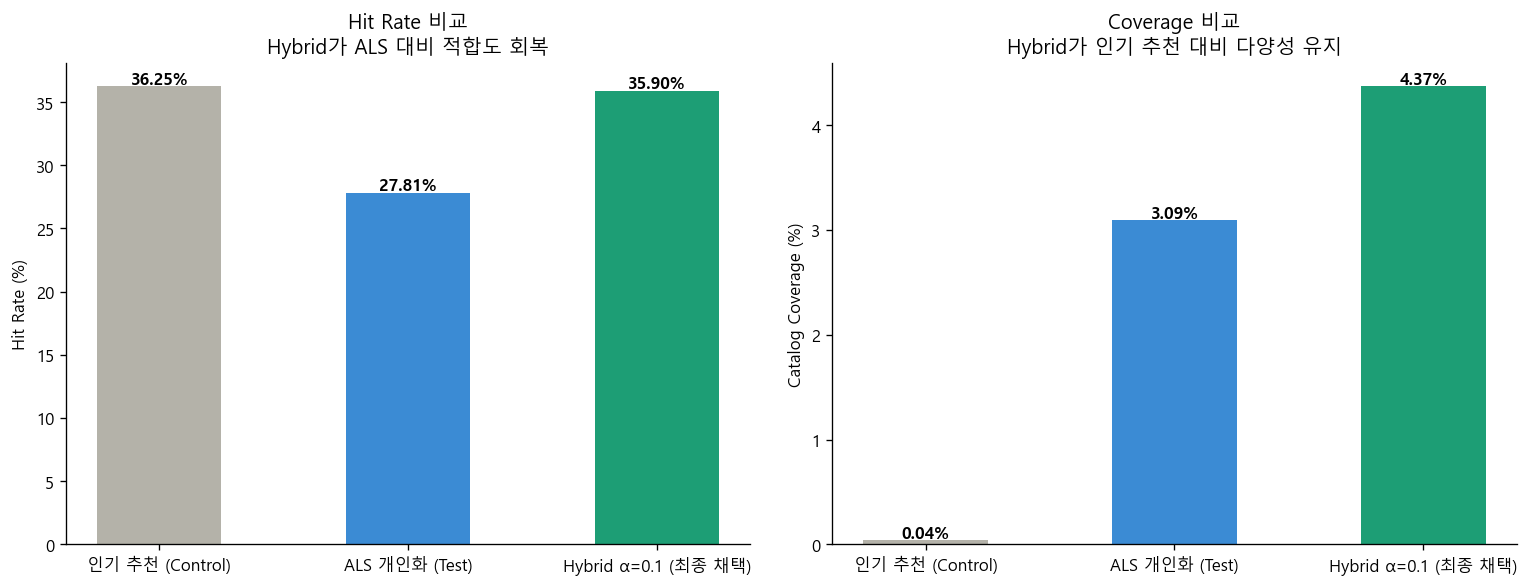

In [7]:
models = results["모델"].tolist()
hit_vals = (results["Hit Rate"] * 100).tolist()
cov_vals = (results["Coverage"] * 100).tolist()
colors = ["#B4B2A9", "#3B8BD4", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(models, hit_vals, color=colors, width=0.5)
for bar, v in zip(bars, hit_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{v:.2f}%",
        ha="center", fontsize=10, fontweight="bold",
    )
axes[0].set_ylabel("Hit Rate (%)")
axes[0].set_title("Hit Rate 비교\nHybrid가 ALS 대비 적합도 회복")

bars2 = axes[1].bar(models, cov_vals, color=colors, width=0.5)
for bar, v in zip(bars2, cov_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{v:.2f}%",
        ha="center", fontsize=10, fontweight="bold",
    )
axes[1].set_ylabel("Catalog Coverage (%)")
axes[1].set_title("Coverage 비교\nHybrid가 인기 추천 대비 다양성 유지")

plt.tight_layout()
plt.savefig("../data/processed/fig_final_comparison.png", bbox_inches="tight")
plt.show()

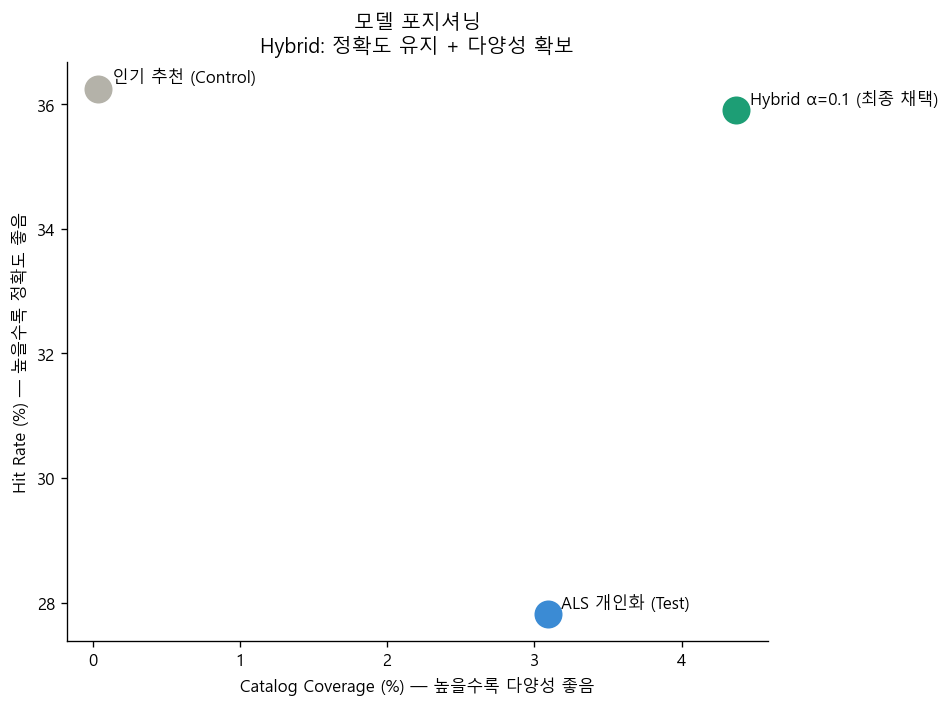

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, row in results.iterrows():
    ax.scatter(
        row["Coverage"] * 100,
        row["Hit Rate"] * 100,
        s=250,
        color=colors[i],
        zorder=5,
    )
    ax.annotate(
        row["모델"],
        xy=(row["Coverage"] * 100, row["Hit Rate"] * 100),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_xlabel("Catalog Coverage (%) — 높을수록 다양성 좋음")
ax.set_ylabel("Hit Rate (%) — 높을수록 정확도 좋음")
ax.set_title("모델 포지셔닝\nHybrid: 정확도 유지 + 다양성 확보")
plt.tight_layout()
plt.savefig("../data/processed/fig_positioning.png", bbox_inches="tight")
plt.show()